# Market Flow and Trading Opportunity
**Author:** Grant Reed 

---
## Testing Order Flow Imbalance in Bitcoin Markets
In this analysis, we replicate and stress test a high-frequency trading (HFT) strategy based on Order Flow Imbalance (OFI) across six major cryptocurrency exchanges. 

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns
import databento as db 
import itertools
import glob 
import os

# 1. Data Assembly 

We load the subsampled dataset consisting of one-sixth of the total trade records.

In [2]:
trades_df = pd.read_parquet(r"C:\Users\under\OneDrive\FINM\BTC-USDT_fewer_trades.parquet", engine = 'fastparquet') # loads data into Pandas DataFrame.

In [3]:
trades_df['ts'] = pd.to_datetime(trades_df['ts']) # ensures 'ts' is datetime and sort by date 
trades_df = trades_df.sort_values('ts').reset_index(drop=True) # reset index after full sort for clean slicing
trades_df.head(2) # check first few rows 

,ts,side,qty,trade_price,Exchange
0,2025-05-01 00:00:00.390986672,B,0.003186,94163.1,OKX
1,2025-05-01 00:00:00.541000261,B,0.000021,94163.1,OKX


In [4]:
unique_exchanges = trades_df['Exchange'].unique() # obtain list of all unique exchanges in our data
unique_exchanges 

array(['OKX', 'GATE_IO', 'COINBASE', 'DERIBIT', 'BITSTAMP', 'BINANCE'],
      dtype=object)

We have trade data collected from six major exchanges during May 2025.

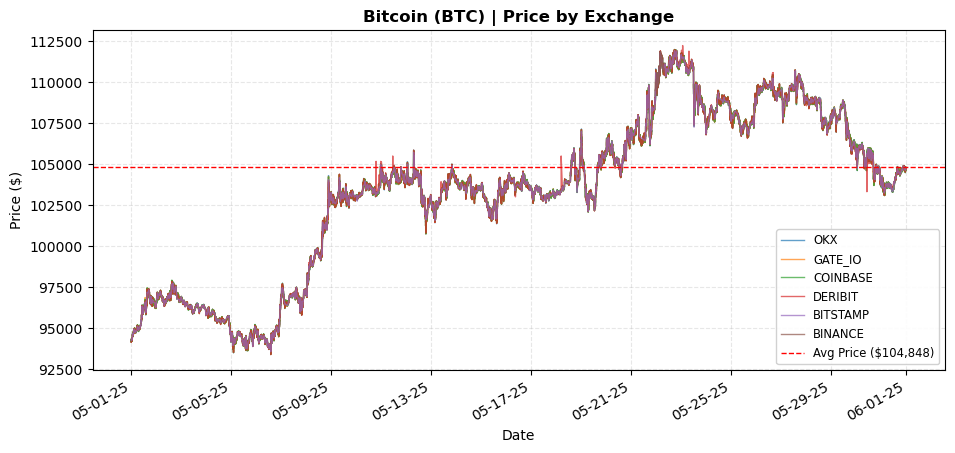

In [5]:
plt.figure(figsize=(11, 5)) # Setup the Plot

exchanges = ['OKX', 'GATE_IO', 'COINBASE', 'DERIBIT', 'BITSTAMP', 'BINANCE'] # List of exchanges to plot

# Loop through and plot each exchange
for ex in exchanges:
    # Filter data for the current exchange
    subset = trades_df[trades_df['Exchange'] == ex]
    
    if not subset.empty:
        # Plot with automatic color cycling
        plt.plot(subset['ts'], subset['trade_price'], 
                 label=ex, linewidth=1, alpha=0.7)

# Average price line 
avg_price = trades_df['trade_price'].mean()
plt.axhline(y=avg_price, color='red', linestyle='--', linewidth=1, 
            label=f'Avg Price (${avg_price:,.0f})')

# Formatting
plt.title("Bitcoin (BTC) | Price by Exchange", fontsize=12, fontweight='bold')
plt.ylabel("Price ($)")
plt.xlabel("Date")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='lower right', fontsize='small', framealpha =0.9)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate() # Rotate labels for readability

plt.show()

We can **observe an upward price trend** over the course of our analyis period. 

This has implications for our calculation of Total P&L, which marks the final inventory to the last observed price.

$\text{Total P\&L} = \underbrace{\text{Realized P\&L}}_{\text{Strategy}} + \underbrace{(\text{Final Inventory} \times \Delta \text{Price})}_{\text{Market Luck}}$

If we end with positive inventory, we will likely benefit from this market regime. 
* Conversely, a negative (Short) ending position would likely be detrimental.

In [6]:
trades_df['sign'] = np.where(trades_df['side'] == 'B', 1, -1) # converts 'side' to a 'sign' signal once for the whole dataset for efficiency
trades_df['signed_qty'] = trades_df['qty'] * trades_df['sign'] 
trades_df.tail(2)

,ts,side,qty,trade_price,Exchange,sign,signed_qty
21295821,2025-05-31 23:59:59.818506808,B,0.000020,104596.4,GATE_IO,1,0.000020
21295822,2025-05-31 23:59:59.875594821,B,0.002868,104596.8,OKX,1,0.002868


We next create the **signed_qty column which distinguishes buying pressure (+) from selling pressure (-)** 

Net order flow is calculated by summing this column over a time period. 

## Deribit Contracts 
Unlike other exchanges that report quantity in BTC, **Deribit uses inverse futures contracts standardized at $10 USD.**

We will fix this unit discrepancy by normalizing the Deribit data within our processing function. 

In [7]:
deribit_check = trades_df[trades_df['Exchange'] == 'DERIBIT'].head(5).copy() # raw Deribit data

if not deribit_check.empty:
    print("--- Raw Deribit Data (Previous) ---")
    print(deribit_check[['trade_price', 'qty']].to_string())
    
    # Calculate what the BTC value WOULD be with the Inverse Formula
    # Assuming standard Deribit BTC contract size = $10 USD
    deribit_check['actual_btc'] = (deribit_check['qty'] * 10.0) / deribit_check['trade_price']
    
    print("\n--- Corrected Deribit Data (Inverse Formula) ---")
    print(deribit_check[['trade_price', 'qty', 'actual_btc']].to_string())
else:
    print("No Deribit data found to check.")

--- Raw Deribit Data (Previous) ---
      trade_price    qty
338       94144.0    1.0
481       94128.0  262.0
892       94175.0  554.0
893       94175.0  318.0
2032      94179.0  889.0

--- Corrected Deribit Data (Inverse Formula) ---
      trade_price    qty  actual_btc
338       94144.0    1.0    0.000106
481       94128.0  262.0    0.027834
892       94175.0  554.0    0.058827
893       94175.0  318.0    0.033767
2032      94179.0  889.0    0.094395


In [8]:
# copy of the data
stats_df = trades_df.copy()

# Fix Deribit Units (Contracts -> BTC)
# Formula: BTC = (Contracts * $10) / Price
mask_deribit = stats_df['Exchange'] == 'DERIBIT'
if mask_deribit.any():
    price_col = 'trade_price' if 'trade_price' in stats_df.columns else 'price'
    stats_df.loc[mask_deribit, 'qty'] = (stats_df.loc[mask_deribit, 'qty'] * 10.0) / stats_df.loc[mask_deribit, price_col]

# Calculate Summary Statistics per Exchange
summary_stats = stats_df.groupby('Exchange').agg({
    'trade_price': ['min', 'max', 'mean'], # Price stats
    'qty': ['count', 'sum', 'mean']        # Volume stats
})

# Flatten the columns for a cleaner look
summary_stats.columns = ['Min Price', 'Max Price', 'Avg Price', 'Total Trades', 'Total Volume (BTC)', 'Avg Trade Size (BTC)']

# Add a "Market Share %" column
total_market_vol = summary_stats['Total Volume (BTC)'].sum()
summary_stats['Market Share %'] = (summary_stats['Total Volume (BTC)'] / total_market_vol) * 100

# Sort by Market Share
summary_stats = summary_stats.sort_values('Market Share %', ascending=False)

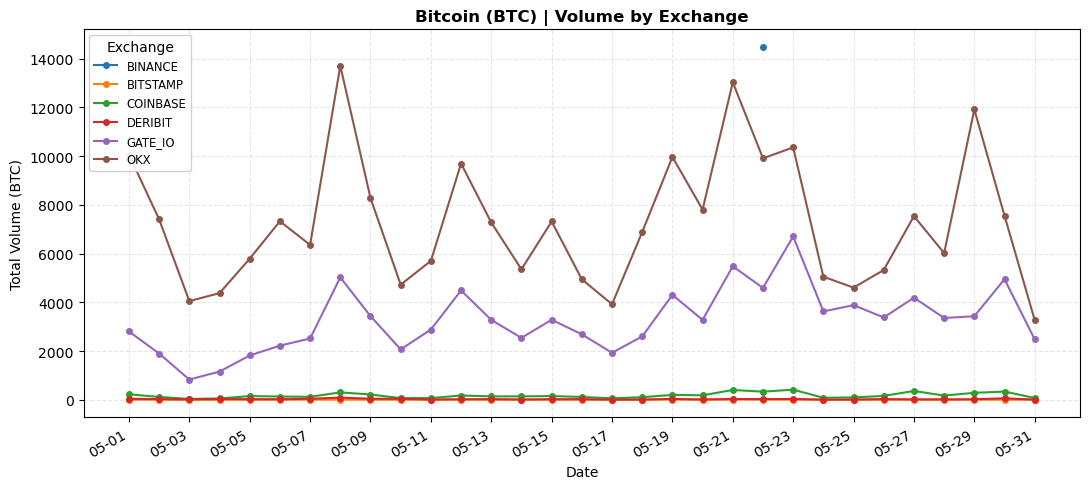

In [9]:
# Prepare Data
vol_df = trades_df.copy()
vol_df['ts'] = pd.to_datetime(vol_df['ts'])

# Apply Deribit Fix 
mask_deribit = vol_df['Exchange'] == 'DERIBIT'
if mask_deribit.any():
    price_col = 'trade_price' if 'trade_price' in vol_df.columns else 'price'
    vol_df.loc[mask_deribit, 'qty'] = (vol_df.loc[mask_deribit, 'qty'] * 10.0) / vol_df.loc[mask_deribit, price_col]

# Aggregate Data
daily_vol = vol_df.groupby([pd.Grouper(key='ts', freq='1D'), 'Exchange'])['qty'].sum().unstack()

# Create Plot 
plt.figure(figsize=(11, 5))

for exchange in daily_vol.columns:
    plt.plot(daily_vol.index, daily_vol[exchange], 
             marker='o', markersize=4, linewidth=1.5, label=exchange)

# Formatting
plt.title("Bitcoin (BTC) | Volume by Exchange", fontsize=12, fontweight='bold')
plt.ylabel("Total Volume (BTC)")
plt.xlabel("Date")
plt.legend(title="Exchange", loc='upper left', fontsize='small', framealpha =0.9)
plt.grid(True, linestyle='--', alpha=0.3)

# Format X-Axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2)) 
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

In [10]:
# Display formatted table
pd.options.display.float_format = '{:,.4f}'.format
summary_stats[['Total Trades', 'Total Volume (BTC)', 'Avg Trade Size (BTC)', 'Market Share %']]

,Total Trades,Total Volume (BTC),Avg Trade Size (BTC),Market Share %
Exchange,,,,
OKX,13458456,"225,494.3981",0.0168,64.8952
GATE_IO,4940305,"101,095.0064",0.0205,29.0942
BINANCE,2374239,"14,478.1756",0.0061,4.1667
COINBASE,453988,"5,491.1888",0.0121,1.5803
DERIBIT,61973,815.6851,0.0132,0.2347
BITSTAMP,6862,100.5069,0.0146,0.0289


After accounting for Deribit's unit sizes, **OKX emerges as the dominant venue with nearly 65% market share**, while Deribit captures a negligible 0.23%.

We can observe our Binance dataset is limited to a single day (May 22). While lacking a month-long history, this 24-hour window provides millions of sequential data points—sufficient to rigorously test the strategy's short-term mechanics

# 2. Primary Functions 
Our full backtest relies on a suite of helper functions to process data and generate signals. 

## Function #1: Preprocess Data
This function preprocesses the raw trade data through three key steps:
* **Unit Normalization**: Converts Deribit's inverse futures contracts into standard BTC quantities.
* **Winsorization**: Clips extreme outliers (1st/99th percentiles) from the raw flow to prevent massive block trades from distorting the signal.
* **Z-Score Standardization**: Normalizes the signal using a rolling window. Measures signal strength by deviation from mean, not absolute value. 

In [11]:
def preprocess_data(df_input, exchange_name, tau_str='100ms'):
    df = df_input.copy()

    # --- STANDARDIZE COLUMN NAMES ---
    price_col = 'trade_price' if 'trade_price' in df.columns else 'price'
    
    # --- HANDLE DERIBIT INVERSE LOGIC ---
    if exchange_name == 'DERIBIT':
        # CONFIRMED: Deribit BTC contracts are $10 USD each.
        # Formula: BTC Amount = (Num Contracts * $10) / Price
        CONTRACT_VALUE_USD = 10.0 
        
        # We overwrite 'qty' with the actual BTC value derived from price
        df['qty'] = (df['qty'] * CONTRACT_VALUE_USD) / df[price_col]
        
    # --- CALCULATE SIGNED QTY ---
    # Now that 'qty' is normalized to base units (BTC), we can sign it
    if 'signed_qty' not in df.columns:
        df['signed_qty'] = np.where(df['side'] == 'buy', df['qty'], -df['qty'])

    # --- FEATURE ENGINEERING ---
    # Set the index to 'ts' (Datetime) so Rolling Windows work
    df = df.set_index('ts').sort_index()
    
    # Calculate Raw Trade Flow
    # Uses the variable 'tau_str' passed as an argument
    df['trade_flow_raw'] = df['signed_qty'].rolling(window=tau_str, closed='left').sum().fillna(0)

    # WINSORIZATION (Clip Outliers)
    upper_limit = df['trade_flow_raw'].quantile(0.99)
    lower_limit = df['trade_flow_raw'].quantile(0.01)
    df['trade_flow_clipped'] = df['trade_flow_raw'].clip(lower=lower_limit, upper=upper_limit)
    
    # STANDARDIZE (Z-Score)
    # Calculate rolling stats on the CLIPPED flow for stability
    rolling_mean = df['trade_flow_clipped'].rolling(window=100).mean()
    rolling_std = df['trade_flow_clipped'].rolling(window=100).std()
    
    # Avoid division by zero
    df['trade_flow'] = (df['trade_flow_clipped'] - rolling_mean) / (rolling_std + 1e-8)
    df['trade_flow'] = df['trade_flow'].fillna(0)
    
    # Reset index so 'ts' becomes a regular column again
    df = df.reset_index()
    
    return df

## Function #2: Generate Signals 

This function executes the core strategy logic by transforming raw order flow into actionable trade decisions via a systematic three-step process:

* **Target Construction**: Calculates the "Forward Return" over a horizon of $T$ seconds (default 1s) to establish the target variable the model attempts to predict. 
* **Model Training**: Performs a chronological split (40% Train / 60% Test). A Linear Regression is fitted on the training set to derive the Beta coefficient, quantifying the signal's predictive power.
* **Dynamic Thresholding**: Applies the Beta to the out-of-sample Test set. Trades are only triggered if the absolute predicted return exceeds a dynamic "J-Threshold," calculated to target a specific participation rate (e.g., top 5% of opportunities).

**Key Inputs**:

**TAU_STR / T_SECONDS**: The lookback window for Order Flow (100ms initially) and the prediction horizon (1s initially). 

**TARGET_PARTICIPATION**: Sets the percentile cutoff for trade execution (e.g., 0.05 targets the top 5% of signals).

**MAX_TRADES_PER_EXCHANGE**: Truncates the dataset to the first 1,000,000 trades to ensure computational efficiency while maintaining statistical significance. 

**COST_BPS**: transaction cost per unit of value (0.00005 for 0.5 bps).

In [12]:
# --- Initial Parameters ---
DEFAULT_TAU_STR = '100ms'
DEFAULT_T_SECONDS = 1
DEFAULT_COST_BPS = 0.00005
DEFAULT_TARGET_PARTICIPATION = 0.05
MAX_TRADES_PER_EXCHANGE = 1_000_000 # Max 1 million trades per exchange

In [13]:
def generate_signals(exchange_df_input, tau_str, t_seconds, target_participation):
    
    exchange_df = exchange_df_input.copy()

    if exchange_df.empty:
        return None, "Empty input DataFrame"

    # --- 1. Target Generation (Forward Returns) ---
    # We DO need to calculate the target here, but NOT the feature.
    exchange_df_indexed = exchange_df.set_index('ts').sort_index()
    
    exchange_df_reset = exchange_df_indexed.reset_index()
    exchange_df_reset['target_time'] = exchange_df_reset['ts'] + pd.Timedelta(seconds=t_seconds)
    
    # Target: Forward Returns
    exchange_df_reset = exchange_df_indexed.reset_index()
    exchange_df_reset['target_time'] = exchange_df_reset['ts'] + pd.Timedelta(seconds=t_seconds)
    
    future_prices = pd.merge_asof(
        exchange_df_reset[['ts', 'target_time']],
        exchange_df_reset[['ts', 'trade_price']],
        left_on='target_time',
        right_on='ts',
        direction='backward',
        suffixes=('', '_future')
    )
    exchange_df_reset['future_price'] = future_prices['trade_price']
    exchange_df_reset['forward_return'] = (exchange_df_reset['future_price'] - exchange_df_reset['trade_price']) / exchange_df_reset['trade_price']
    
    # Clean data
    exchange_df_final = exchange_df_reset.dropna(subset=['forward_return']).set_index('ts').sort_index()

    # --- 2. Train/Test Split ---
    split_index = int(len(exchange_df_final) * 0.40)
    train_df = exchange_df_final.iloc[:split_index].copy()
    test_df = exchange_df_final.iloc[split_index:].copy()

    if len(train_df) < 10 or len(test_df) < 10:
        return None, "Insufficient data for Train/Test split"

    # --- 3. Regression (Alpha Model) ---
    X_train = train_df[['trade_flow']].values
    y_train = train_df['forward_return'].values

    # Check for variance to avoid singular matrix errors
    if np.std(X_train) == 0:
        return None, "No variance in trade_flow (feature is constant)"

    model = LinearRegression()
    model.fit(X_train, y_train)
    beta = model.coef_[0]

    # --- 4. Prediction & Signal ---
    test_df['predicted_return'] = model.predict(test_df[['trade_flow']].values)
    
    # We remove the 'max(..., MIN_EXPECTED_RETURN)' logic to force 5% participation.
    # This fulfills the professor's requirement "5% is a nice target".
    
    j_threshold = test_df['predicted_return'].abs().quantile(1 - target_participation)
    
    # Check if threshold is 0 (can happen if signals are very weak/sparse)
    if j_threshold == 0:
        j_threshold = 1e-9 # Force a tiny non-zero threshold to catch non-zero signals

    test_df['trade_signal'] = np.where(test_df['predicted_return'].abs() > j_threshold, 1, 0)

    # Extract executed trades
    executed_trades = test_df[test_df['trade_signal'] == 1].copy()
    
    if executed_trades.empty:
        return None, "No trades triggered (Signal too weak)"

    executed_trades.attrs['beta'] = beta 
    executed_trades.attrs['test_size'] = len(test_df)  # <--- SAVE TEST SET SIZE
    
    return executed_trades, "Success"

## Function #3: Calculate Accounting 

This function serves as the financial engine of our backtest, simulating the lifecycle of each trade and tracking the evolving portfolio state. 

### P&L Methodology: Cash Flow + Mark-to-Market 
We employ a continuous accounting method that tracks the cumulative Net Cash Change (realized profits minus fees) and adds the theoretical liquidation value of the final inventory to determine Total P&L.

The function executes three critical operations:

* **Inventory Limits**: Enforces a strict max_inventory_limit (initially set to 10 units). Without this cap, the strategy could accumulate massive directional exposure (hundreds of BTC). The limit acts as a risk control to prevent massive drawdowns.

* **Cash Flow Accounting**: Every trade immediately adjusts the cash balance by recording the capital inflow/outflow and deducting transaction fees (cost_bps).

* **Mark-to-Market Valuation**: At every tick, the function calculates "Unrealized P&L" by comparing the Weighted Average Cost (WAC) of the current inventory against the latest market price. 

In [14]:
def calculate_accounting(executed_trades_input, cost_bps, max_inventory_limit=10):
    if executed_trades_input is None or executed_trades_input.empty:
        return {
            'Total Net P&L': 0.0,
            'Message': 'No trades to process'
        }

    executed_trades = executed_trades_input.copy()
    
    # Setup Columns 
    executed_trades['my_side'] = np.sign(executed_trades['predicted_return'])
    executed_trades['my_signed_qty'] = executed_trades['my_side'] * executed_trades['qty']
    
    # Initialize P&L columns 
    executed_trades['cost_usd'] = 0.0
    executed_trades['cash_change'] = 0.0
    executed_trades['net_cash_change'] = 0.0

    executed_trades = executed_trades.reset_index(names='original_ts')

    # Inventory Loop
    inventory_history = []
    
    # Track average costs for Unrealized P&L
    avg_cost_long_data = []
    avg_cost_short_data = []

    current_long_qty = 0.0
    current_long_value = 0.0
    current_short_qty = 0.0
    current_short_value = 0.0
    
    for idx, row in executed_trades.iterrows():
        raw_qty_change = row['my_signed_qty']
        price = row['trade_price']
        
        # --- INVENTORY GUARDRAIL CHECK ---
        projected_inventory = (current_long_qty - current_short_qty) + raw_qty_change
        
        qty_executed = raw_qty_change # Default to full execution
        
        # Check Limit
        if abs(projected_inventory) > max_inventory_limit:
            # LOGIC: Only allow reducing the position.
            # If we are Long and want to Buy more -> BLOCK (qty=0)
            if (current_long_qty - current_short_qty) > 0 and raw_qty_change > 0:
                qty_executed = 0 
            # If we are Short and want to Sell more -> BLOCK (qty=0)
            elif (current_long_qty - current_short_qty) < 0 and raw_qty_change < 0:
                qty_executed = 0
                
        # ---  EXECUTE TRADE (If not blocked) ---
        if qty_executed != 0:
            # Calculate Financials using ACTUAL executed quantity
            # Note: We use abs(qty_executed) because fee is based on volume
            fee = abs(qty_executed) * price * cost_bps
            cash_impact = -1 * qty_executed * price
            
            # Update the DataFrame for this specific row
            executed_trades.at[idx, 'cost_usd'] = fee
            executed_trades.at[idx, 'cash_change'] = cash_impact
            executed_trades.at[idx, 'net_cash_change'] = cash_impact - fee
            
            # Update Inventory State (FIFO / W Avg)
            if qty_executed > 0: # BUY
                current_long_qty += qty_executed
                current_long_value += qty_executed * price
                if current_short_qty > 0:
                    cover_amt = min(current_short_qty, qty_executed)
                    current_short_qty -= cover_amt
                    if (current_short_qty + cover_amt) > 0:
                        current_short_value -= cover_amt * (current_short_value / (current_short_qty + cover_amt))
                    else: current_short_value = 0.0

            elif qty_executed < 0: # SELL
                abs_qty = abs(qty_executed)
                current_short_qty += abs_qty
                current_short_value += abs_qty * price
                if current_long_qty > 0:
                    sell_amt = min(current_long_qty, abs_qty)
                    current_long_qty -= sell_amt
                    if (current_long_qty + sell_amt) > 0:
                        current_long_value -= sell_amt * (current_long_value / (current_long_qty + sell_amt))
                    else: current_long_value = 0.0

        # Precision cleanup
        if abs(current_long_qty) < 1e-9: current_long_qty = 0.0
        if abs(current_long_value) < 1e-9: current_long_value = 0.0
        if abs(current_short_qty) < 1e-9: current_short_qty = 0.0
        if abs(current_short_value) < 1e-9: current_short_value = 0.0

        # Store State
        inventory_history.append(current_long_qty - current_short_qty)
        
        ac_long = current_long_value / current_long_qty if current_long_qty > 0 else np.nan
        ac_short = current_short_value / current_short_qty if current_short_qty > 0 else np.nan
        
        avg_cost_long_data.append(ac_long)
        avg_cost_short_data.append(ac_short)

    # Assign Computed Lists back to DataFrame
    executed_trades['inventory'] = inventory_history
    executed_trades['avg_cost_long'] = avg_cost_long_data
    executed_trades['avg_cost_short'] = avg_cost_short_data

    # Calculate Unrealized P&L (Mark-to-Market)
    unrealized_pnl = []
    for idx, row in executed_trades.iterrows():
        inv = row['inventory']
        mkt_price = row['trade_price']
        
        if inv > 0 and pd.notna(row['avg_cost_long']):
            unrealized_pnl.append((mkt_price - row['avg_cost_long']) * inv)
        elif inv < 0 and pd.notna(row['avg_cost_short']):
            unrealized_pnl.append((row['avg_cost_short'] - mkt_price) * abs(inv))
        else:
            unrealized_pnl.append(0.0)
            
    executed_trades['unrealized_pnl'] = unrealized_pnl

    # --- FINAL AGGREGATION ---
    # Get the final state
    ending_cash_balance = executed_trades['net_cash_change'].sum()
    ending_gross_cash = executed_trades['cash_change'].sum()
    final_inventory_qty = executed_trades['inventory'].iloc[-1]
    final_price = executed_trades['trade_price'].iloc[-1]
    
    # Calculate Portfolio Value (Cash + Asset Value)
    # We add the full market value of the inventory to the cash balance
    inventory_value = final_inventory_qty * final_price
    
    total_net_pnl = ending_cash_balance + inventory_value
    total_gross_pnl = ending_gross_cash + inventory_value
    
    return {
        'Total Trades': len(executed_trades[executed_trades['net_cash_change'] != 0]), # Only count executed trades
        'Total Net P&L': total_net_pnl,
        'Total Gross P&L': total_gross_pnl,
        'Unrealized P&L (Final)': unrealized_pnl[-1],
        'Fees Paid': executed_trades['cost_usd'].sum(),
        'Final Inventory': executed_trades['inventory'].iloc[-1],
        'Trades_DF': executed_trades[['original_ts', 'inventory', 'net_cash_change', 'unrealized_pnl', 'trade_price']]
    }

# 3. Sensitivity Analysis 
In this section, we perform a sensitivity analysis on the strategy's core parameters to optimize our strategy's performance. 

We selected OKX as our primary testing venue due to its dominant liquidity and transaction volume.

## Signal Strength - J Threshold
We model the expected return ($\hat{r}$) as a linear function of the Order Flow Imbalance (OFI) calculated over the interval $\tau$:

$\hat{r} = \beta \times \text{Trade Flow}_{\tau}$

A trade is executed only when the absolute expected return exceeds a conviction threshold, $J$:

$|\hat{r}| > J$

**We vary the target_participation parameter**—which dynamically calibrates $J$ based on signal percentiles. 

In [15]:
def run_sensitivity_sweep(exchange_name, targets=[0.01, 0.02, 0.05, 0.10]):
    raw_df = trades_df[trades_df['Exchange'] == exchange_name].copy()
    if len(raw_df) > MAX_TRADES_PER_EXCHANGE:
        raw_df = raw_df.iloc[:MAX_TRADES_PER_EXCHANGE].copy()
    clean_df = preprocess_data(raw_df, exchange_name)
    
    results = []
    
    # Loop through targets
    for target in targets:
        
        # Generate Signals with NEW target
        signals, msg = generate_signals(
            clean_df, 
            DEFAULT_TAU_STR, 
            DEFAULT_T_SECONDS, 
            target_participation=target # <--- Varying this
        )
        
        if signals is not None:
            # Run Accounting (Standard Capped)
            stats = calculate_accounting(signals, DEFAULT_COST_BPS, max_inventory_limit=10)
            
            # Calculate Metrics
            total_trades = stats['Total Trades']
            net_pnl = stats['Total Net P&L']
            # Calculate P&L per trade 
            pnl_per_trade = net_pnl / total_trades if total_trades > 0 else 0
            
            # Calculate Threshold in %
            threshold_val = signals['predicted_return'].abs().min()
            
            results.append({
                'Target %': target * 100,
                'Threshold j (%)': threshold_val * 100, # <--- Converted to %
                'Total Trades': total_trades,
                'Total Net P&L ($)': net_pnl,
                'Avg P&L per Trade ($)': pnl_per_trade
            })
            
    return pd.DataFrame(results)

In [16]:
sensitivity_df = run_sensitivity_sweep('OKX', targets=[0.005, 0.01, 0.05, 0.10, 0.20])
pd.options.display.float_format = '{:,.4f}'.format
sensitivity_df

,Target %,Threshold j (%),Total Trades,Total Net P&L ($),Avg P&L per Trade ($)
0,0.5000,0.0148,2792,"-134,137.5678",-48.0435
1,1.0000,0.0122,5422,"-518,880.0913",-95.6990
2,5.0000,0.0074,26597,"-43,734.1350",-1.6443
3,10.0000,0.0055,51555,"393,252.7157",7.6278
4,20.0000,0.0034,99524,"471,709.4733",4.7397


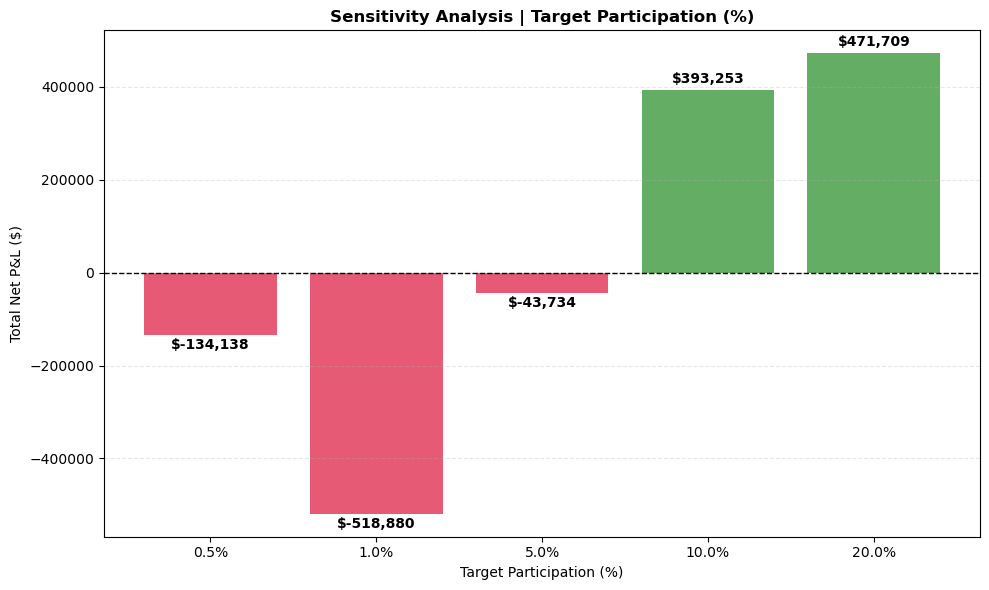

In [17]:
def plot_sensitivity_dynamic(df):
    plt.figure(figsize=(10, 6))
    
    targets = df['Target %'].astype(str) + '%'   # Extract data directly from the DataFrame
    pnl_values = df['Total Net P&L ($)']

    colors = ['forestgreen' if x > 0 else 'crimson' for x in pnl_values]
    
    bars = plt.bar(targets, pnl_values, color=colors, alpha=0.7)     # Bar Plot
    
    plt.axhline(0, color='black', linewidth=1, linestyle='--')     # Add a horizontal line at 0 (Breakeven)
    
    plt.title("Sensitivity Analysis | Target Participation (%)", fontsize=12, fontweight='bold')
    
    plt.xlabel("Target Participation (%)")
    plt.ylabel("Total Net P&L ($)")
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        xy_pos = (bar.get_x() + bar.get_width() / 2, height)
        text_pos = (0, 5) if height > 0 else (0, -10) 
        
        plt.annotate(f'${height:,.0f}', xy=xy_pos, xytext=text_pos,
                     textcoords="offset points", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Run it with your existing dataframe
plot_sensitivity_dynamic(sensitivity_df)

The Order Flow Imbalance signal appears **most effective at moderate participation rates (10-20%).**

This translates to a target $j$ threshold range of approx. 0.35 to .55 basis points. 

## Lookback Window - TAU Interval 
TAU sets the historical interval ($X$ milliseconds) over which signed order flow is summed. 

In [18]:
# --- CONFIGURATION ---
TEST_EXCHANGE = 'OKX'
TAU_VALUES_TO_TEST = ['10ms', '50ms', '100ms', '500ms', '1s', '5s','10s']

raw_df = trades_df[trades_df['Exchange'] == TEST_EXCHANGE].copy()
if len(raw_df) > MAX_TRADES_PER_EXCHANGE:
    raw_df = raw_df.iloc[:MAX_TRADES_PER_EXCHANGE].copy()

results = []

for tau in TAU_VALUES_TO_TEST:
    
    # reprocess with SPECIFIC Tau
    clean_df = preprocess_data(raw_df, TEST_EXCHANGE, tau_str=tau)
    
    # Generate Signals
    signals, msg = generate_signals(
        clean_df, 
        tau,  # Pass tau here too for logging/naming
        DEFAULT_T_SECONDS, 
        DEFAULT_TARGET_PARTICIPATION # Keep fixed 
    )
    
    if signals is not None:
        # Accounting
        stats = calculate_accounting(signals, DEFAULT_COST_BPS, max_inventory_limit=10)
        
        # Save Metrics
        beta = signals.attrs.get('beta', 0)
        
        results.append({
            'Tau': tau,
            'Beta': beta,
            'Total Net P&L': stats['Total Net P&L'],
            'Total Trades': stats['Total Trades']
        })

In [19]:
# --- RESULTS ---
tau_results_df = pd.DataFrame(results)
pd.options.display.float_format = '{:,.6f}'.format
tau_results_df

,Tau,Beta,Total Net P&L,Total Trades
0,10ms,0.000020,"-168,338.331523",26331
1,50ms,0.000022,"-192,390.152297",26462
2,100ms,0.000023,"-43,734.134958",26597
3,500ms,0.000024,"125,135.503199",25763
4,1s,0.000023,"57,690.239139",25782
5,5s,0.000019,"382,660.463555",22657
6,10s,0.000018,"254,259.247225",21781


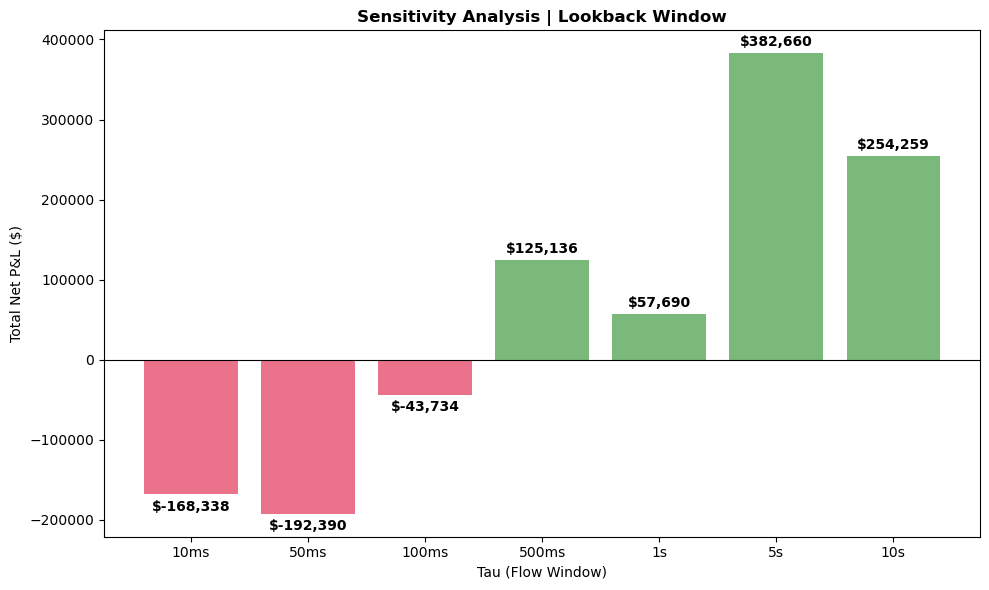

In [20]:
def plot_tau_results(df):
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Plot P&L (Bars)
    colors = ['forestgreen' if x > 0 else 'crimson' for x in df['Total Net P&L']]

    bars = ax1.bar(df['Tau'], df['Total Net P&L'], color=colors, alpha=0.6, label='Net P&L')
    
    ax1.set_xlabel('Tau (Flow Window)')
    ax1.set_ylabel('Total Net P&L ($)', color='black')
    ax1.axhline(0, color='black', linewidth=0.8)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        xy_pos = (bar.get_x() + bar.get_width() / 2, height)
        
        # Offset text: Above bar for positive, Below bar for negative
        text_pos = (0, 5) if height > 0 else (0, -12) 
        
        # Use ax1.annotate instead of plt.annotate to ensure it attaches to the right axes
        ax1.annotate(f'${height:,.0f}', xy=xy_pos, xytext=text_pos,
                     textcoords="offset points", ha='center', fontweight='bold')
    
    plt.title(f"Sensitivity Analysis | Lookback Window", fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()

plot_tau_results(tau_results_df)

Profitability emerges as the window widens. **The strategy performs best with a 5-second lookback.**

Tighter lookback windows (10ms–100ms) result in consistent losses.

## Prediction Horizon - T 
We adjust the Prediction Horizon ($T$), which sets the future interval over which the model forecasts returns (e.g., predicting the price 1 second ahead). 
* Consequently this parameter sets the strategy's effective holding period. 

In [21]:
# --- CONFIGURATION ---
TEST_EXCHANGE = 'OKX'
OPTIMAL_TAU = '5s'  # Using best finding from the previous step
HORIZONS_TO_TEST = [1, 5, 10, 30, 60] # In Seconds

# 1. Get Clean Data (Preprocess with the OPTIMAL Tau)
raw_df = trades_df[trades_df['Exchange'] == TEST_EXCHANGE].copy()
if len(raw_df) > MAX_TRADES_PER_EXCHANGE:
    raw_df = raw_df.iloc[:MAX_TRADES_PER_EXCHANGE].copy()

# Pre-calculate the flow feature once (since Tau is fixed)
clean_df = preprocess_data(raw_df, TEST_EXCHANGE, tau_str=OPTIMAL_TAU)

results = []

for t_secs in HORIZONS_TO_TEST:
    
    # 2. Generate Signals
    signals, msg = generate_signals(
        clean_df, 
        OPTIMAL_TAU, 
        t_secs,  # <--- Varying this
        DEFAULT_TARGET_PARTICIPATION # Fixed at 5%
    )
    
    if signals is not None:
        # 3. Accounting (Capped)
        stats = calculate_accounting(signals, DEFAULT_COST_BPS, max_inventory_limit=10)
        
        # 4. Save Metrics
        beta = signals.attrs.get('beta', 0)
        
        results.append({
            'Horizon (T)': f"{t_secs}s",
            'Beta': beta,
            'Total Net P&L': stats['Total Net P&L'],
            'Total Trades': stats['Total Trades'],
            'Avg P&L per Trade': stats['Total Net P&L'] / stats['Total Trades'] if stats['Total Trades'] > 0 else 0
        })

In [22]:
# --- RESULTS ---
horizon_df = pd.DataFrame(results)
pd.options.display.float_format = '{:,.4f}'.format
horizon_df

,Horizon (T),Beta,Total Net P&L,Total Trades,Avg P&L per Trade
0,1s,0.0000,"382,660.4636",22657,16.8893
1,5s,0.0000,"-284,294.1745",17886,-15.8948
2,10s,0.0000,"-300,426.8983",18734,-16.0365
3,30s,0.0000,"-156,211.7944",9177,-17.0221
4,60s,0.0000,"-239,862.9962",12798,-18.7422


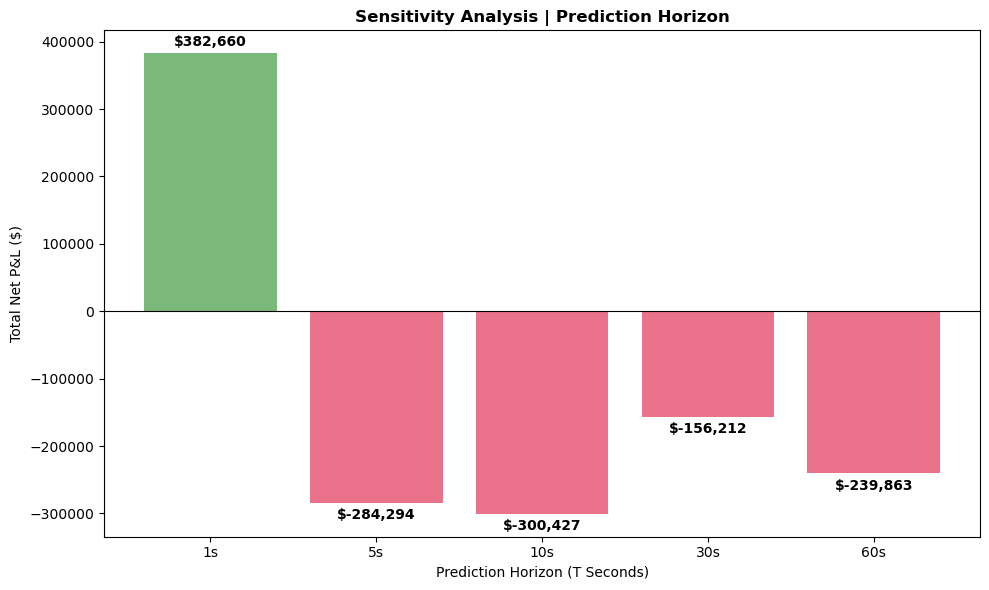

In [23]:
def plot_horizon_results(df):
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Plot P&L (Bars)
    colors = ['forestgreen' if x > 0 else 'crimson' for x in df['Total Net P&L']]
    
    # FIX: Assign the plot object to 'bars'
    bars = ax1.bar(df['Horizon (T)'], df['Total Net P&L'], color=colors, alpha=0.6, label='Net P&L')
    
    ax1.set_xlabel('Prediction Horizon (T Seconds)')
    ax1.set_ylabel('Total Net P&L ($)', color='black')
    ax1.axhline(0, color='black', linewidth=0.8)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        xy_pos = (bar.get_x() + bar.get_width() / 2, height)
        
        # Offset text: Above bar for positive, Below bar for negative
        text_pos = (0, 5) if height > 0 else (0, -12) 
        
        ax1.annotate(f'${height:,.0f}', xy=xy_pos, xytext=text_pos,
                     textcoords="offset points", ha='center', fontweight='bold')
    
    plt.title(f"Sensitivity Analysis | Prediction Horizon", fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()

# Run it
plot_horizon_results(horizon_df)

While highly **effective at forecasting price movements over a 1-second horizon**, our strategy's predictive value appears to evaporate completely by the 5-second mark.

# 4. Full Backtest - All Exchanges 
Based on our three sensitivity tests, we have defined the "Golden Configuration" for our strategy **using the OKX testing set**: 

**Participation: 10–20%** (Targeting moderate conviction, avoiding extreme outliers).

**Lookback ($\tau$): 5 Seconds** (Aggregating flow long enough to find sustained pressure).

**Horizon ($T$): 1 Second** (Predicting only the immediate impact). 

We now deploy this optimized parameter set across all six exchanges to evaluate the strategy's holistic performance.

In [24]:
# --- Define Strategy Parameters ---
DEFAULT_TAU_STR = '5s' # looback window 
DEFAULT_T_SECONDS = 1 # prediction horizon 
DEFAULT_COST_BPS = 0.00005 # cost per transaction value 
DEFAULT_TARGET_PARTICIPATION = 0.15 # target participation rate 
MAX_TRADES_PER_EXCHANGE = 1_000_000 # max 1 million trades per exchange

In [25]:
all_results = {}
for exchange in unique_exchanges:
    
    # 1. Get Data for Current Exchange
    # We use .copy() to ensure we don't get SettingWithCopy warnings later
    raw_df = trades_df[trades_df['Exchange'] == exchange].copy()
    
    if len(raw_df) > MAX_TRADES_PER_EXCHANGE:
        raw_df = raw_df.iloc[:MAX_TRADES_PER_EXCHANGE].copy()
    else:
        print(f"  [Truncation] Dataset size ({len(raw_df)} rows) is within limits. Processing full set.")

    # 2. Apply Data Fixes (Units & Feature Z-Scores)
    # This must happen AFTER truncation to save time/memory
    clean_df = preprocess_data(raw_df, exchange)
    
    # 3. Generate Signals (Uses Z-Scores + Hurdle Rate)
    trades_df_output, msg = generate_signals(
        clean_df, 
        DEFAULT_TAU_STR, 
        DEFAULT_T_SECONDS, 
        DEFAULT_TARGET_PARTICIPATION
    )
    
    if trades_df_output is None:
        all_results[exchange] = {'Message': msg}
        continue
        
    # Run Accounting 
    stats = calculate_accounting(trades_df_output, DEFAULT_COST_BPS)
    stats['Beta'] = trades_df_output.attrs.get('beta', np.nan)

    # Retrieve Metadeta 
    stats['Beta'] = trades_df_output.attrs.get('beta', np.nan)
    stats['Test Size'] = trades_df_output.attrs.get('test_size', 1) # Default to 1 to avoid div/0
    
    all_results[exchange] = stats

  [Truncation] Dataset size (453988 rows) is within limits. Processing full set.
  [Truncation] Dataset size (61973 rows) is within limits. Processing full set.
  [Truncation] Dataset size (6862 rows) is within limits. Processing full set.


In [26]:
# --- Display Final Summary Table ---
results_list = []

for ex, m in all_results.items():
    if 'Total Net P&L' in m:
        test_size = m.get('Test Size', 1) 
        participation_rate = m['Total Trades'] / test_size
        
        results_list.append({
            'Exchange': ex,
            'Beta': m['Beta'],
            'Trades': m['Total Trades'],
            'Participation %': participation_rate * 100, 
            'Net P&L': m['Total Net P&L'],
            'Final Inv': m['Final Inventory']
        })
    else:
        results_list.append({
            'Exchange': ex,
            'Trades': 0,
            'Participation %': 0.0,
            'Net P&L': 0.0,
            'Final Inv': 0.0,
            'Note': m.get('Message', 'Error')
        })

summary_df = pd.DataFrame(results_list)

# Define specific formatting for each column
format_mapping = {
    'Beta': '{:,.6f}',
    'Participation %': '{:,.2f}%',  # Added % sign for clarity
    'Net P&L': '${:,.0f}',          # Added $ sign for clarity
    'Final Inv': '{:,.2f}'}

# Apply formatting 
styled_df = summary_df.style.format(format_mapping, na_rep="-")
display(styled_df)

,Exchange,Beta,Trades,Participation %,Net P&L,Final Inv
0,OKX,0.000023,75513,12.59%,"$575,712",8.75
1,GATE_IO,0.000032,84462,14.08%,"$-89,412",-1.72
2,COINBASE,0.000034,40177,14.75%,"$-150,631",4.16
3,DERIBIT,0.000011,3803,10.23%,"$-5,629",-9.87
4,BITSTAMP,0.000057,614,14.91%,"$-401,670",-3.41
5,BINANCE,0.000021,79043,13.17%,"$7,119",10.00


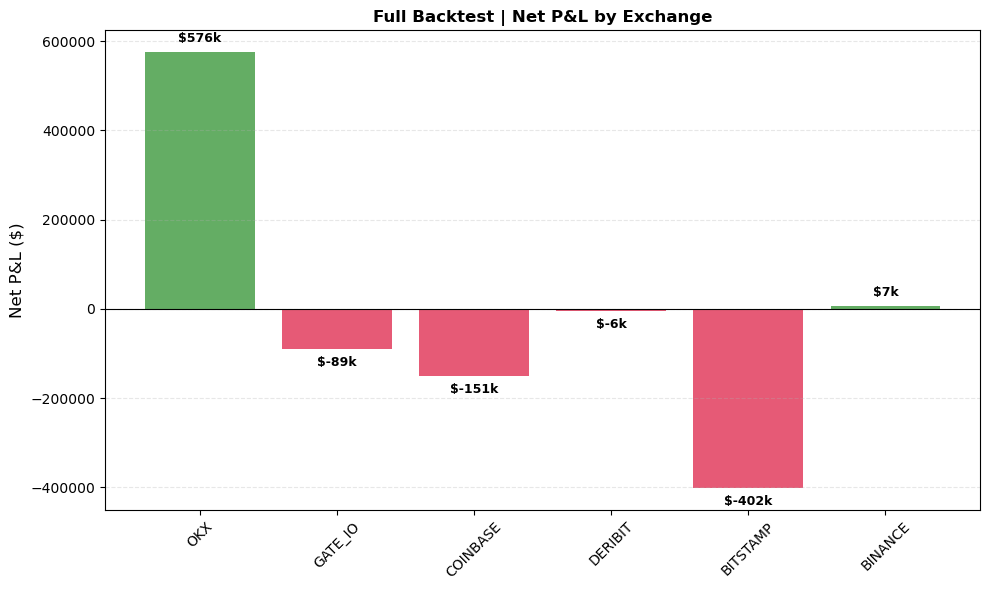

In [27]:
if 'summary_df' in locals() and not summary_df.empty:
    
    # Create single figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Color logic: Green if P&L > 0, Red if < 0
    colors = ['forestgreen' if x >= 0 else 'crimson' for x in summary_df['Net P&L']]

    # Plot
    bars = ax.bar(summary_df['Exchange'], summary_df['Net P&L'], color=colors, alpha=0.7)

    # Formatting
    ax.set_title('Full Backtest | Net P&L by Exchange', fontsize=12, fontweight='bold')
    ax.set_ylabel('Net P&L ($)', fontsize=12)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

    # Add value labels dynamically
    for bar in bars:
        height = bar.get_height()
        
        # Determine vertical offset (points) and alignment
        # Positive: 5 points UP, Bottom aligned
        # Negative: 5 points DOWN, Top aligned
        xy_offset = (0, 5) if height >= 0 else (0, -5)
        vert_align = 'bottom' if height >= 0 else 'top'
        
        ax.annotate(f'${height/1000:,.0f}k',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=xy_offset,          # Offset in points (pixels) not data
                    textcoords="offset points", 
                    ha='center', va=vert_align, 
                    fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

The results demonstrate **strong parameter sensitivity** and likely **overfitting to the OKX microstructure.**
* Since we optimized our core parameters specifically for this dataset, the strategy perfectly captures the dynamic of OKX's order book

Binance is the only other profitable venue -- as the market leader with deep liquidity similar to OKX, its microstructure likely resembles OKX’s enough for the parameters to translate.

# 5. Statistical Stability (Beta Analysis)
To ensure our model's predictive power is not a statistical anomaly (or 'lucky fit'), we perform a Beta Stability Analysis.

We segment the training dataset into five distinct chronological blocks to monitor the evolution of the $\beta$ coefficient over time. 

In [28]:
# --- Define Helper Function ---
def get_beta_stats(df, exchange_name, n_splits=5):
    chunk_size = len(df) // n_splits
    betas = []
    period_data = {} 

    for i in range(n_splits):
        start = i * chunk_size
        end = (i + 1) * chunk_size
        chunk = df.iloc[start:end]
        
        X = chunk[['trade_flow']].values
        y = chunk['forward_return'].values
        
        if len(X) > 100 and np.std(X) > 0:
            model = LinearRegression().fit(X, y)
            beta = model.coef_[0]
        else:
            beta = 0.0
        
        betas.append(beta)
        period_data[f'Period {i+1}'] = beta

    beta_mean = np.mean(betas)
    beta_std = np.std(betas)
    cv = beta_std / abs(beta_mean) if (beta_mean != 0) else 0.0
    status = "UNSTABLE" if cv > 0.5 else "STABLE"

    row = {
        "Exchange": exchange_name,
        "Total Rows": len(df),
        "Mean Beta": beta_mean,
        "Std Dev": beta_std,
        "Variation": cv,
        "Status": status
    }
    row.update(period_data)
    return row

# --- Main Loop ---
results_list = []
exchanges = ['OKX', 'GATE_IO', 'COINBASE', 'DERIBIT', 'BITSTAMP', 'BINANCE']

for exchange in exchanges:
    raw_data = trades_df[trades_df['Exchange'] == exchange].iloc[:MAX_TRADES_PER_EXCHANGE].copy()
    
    if raw_data.empty:
        continue

    clean_df = preprocess_data(raw_data, exchange)
    
    # Calculate Forward Returns
    df_res = clean_df.reset_index()
    df_res['target_time'] = df_res['ts'] + pd.Timedelta(seconds=1)
    future_lookup = df_res[['ts', 'trade_price']].copy()
    future_lookup.columns = ['ts', 'trade_price_fut'] 
    
    merged = pd.merge_asof(
        df_res[['ts', 'target_time']],      
        future_lookup,                      
        left_on='target_time',              
        right_on='ts',                      
        direction='backward'
    )
    
    clean_df['forward_return'] = (merged['trade_price_fut'].values - clean_df['trade_price'].values) / clean_df['trade_price'].values
    clean_df = clean_df.dropna(subset=['trade_flow', 'forward_return'])

    stats = get_beta_stats(clean_df, exchange)
    results_list.append(stats)

# --- Create, Reorder & Style ---
beta_df = pd.DataFrame(results_list)

# REORDERING LOGIC: Exchange -> Status -> Everything else
cols = ['Exchange', 'Status'] + [c for c in beta_df.columns if c not in ['Exchange', 'Status']]
beta_df = beta_df[cols]

# Formatting
format_mapping = {
    'Total Rows': '{:,}',
    'Mean Beta': '{:.6f}',
    'Std Dev': '{:.6f}',
    'Variation': '{:.1%}',
    'Period 1': '{:.6f}',
    'Period 2': '{:.6f}',
    'Period 3': '{:.6f}',
    'Period 4': '{:.6f}',
    'Period 5': '{:.6f}',
}

styled_beta_df = beta_df.style.format(format_mapping).map(
    lambda v: 'color: red; font-weight: bold;' if v == 'UNSTABLE' else 'color: green; font-weight: bold;',
    subset=['Status']
)

display(styled_beta_df)

,Exchange,Status,Total Rows,Mean Beta,Std Dev,Variation,Period 1,Period 2,Period 3,Period 4,Period 5
0,OKX,STABLE,"1,000,000",0.000022,0.000002,8.6%,0.000025,0.000022,0.000023,0.000023,0.000019
1,GATE_IO,STABLE,"1,000,000",0.000035,0.000003,9.4%,0.000035,0.000029,0.000034,0.000039,0.000037
2,COINBASE,STABLE,"453,988",0.000038,0.000005,12.1%,0.000031,0.000037,0.000038,0.000045,0.000042
3,DERIBIT,UNSTABLE,"61,973",0.000007,0.000005,63.4%,0.000007,0.000014,0.000000,0.000009,0.000006
4,BITSTAMP,UNSTABLE,"6,862",0.000037,0.000035,95.9%,0.000005,0.000096,0.000057,0.000009,0.000015
5,BINANCE,STABLE,"1,000,000",0.000021,0.000001,3.0%,0.000021,0.000022,0.000021,0.000020,0.000020


## Beta Stability Results (All Exchanges) 
On high-volume exchanges (Binance, OKX), the $\beta$ coefficient remains remarkably stable (3%–12% variation) across all time periods. 

Instability is observed only on venues with insufficient data (Deribit, Bitstamp) -- where the signal's degradation is likely due to data sparsity. 

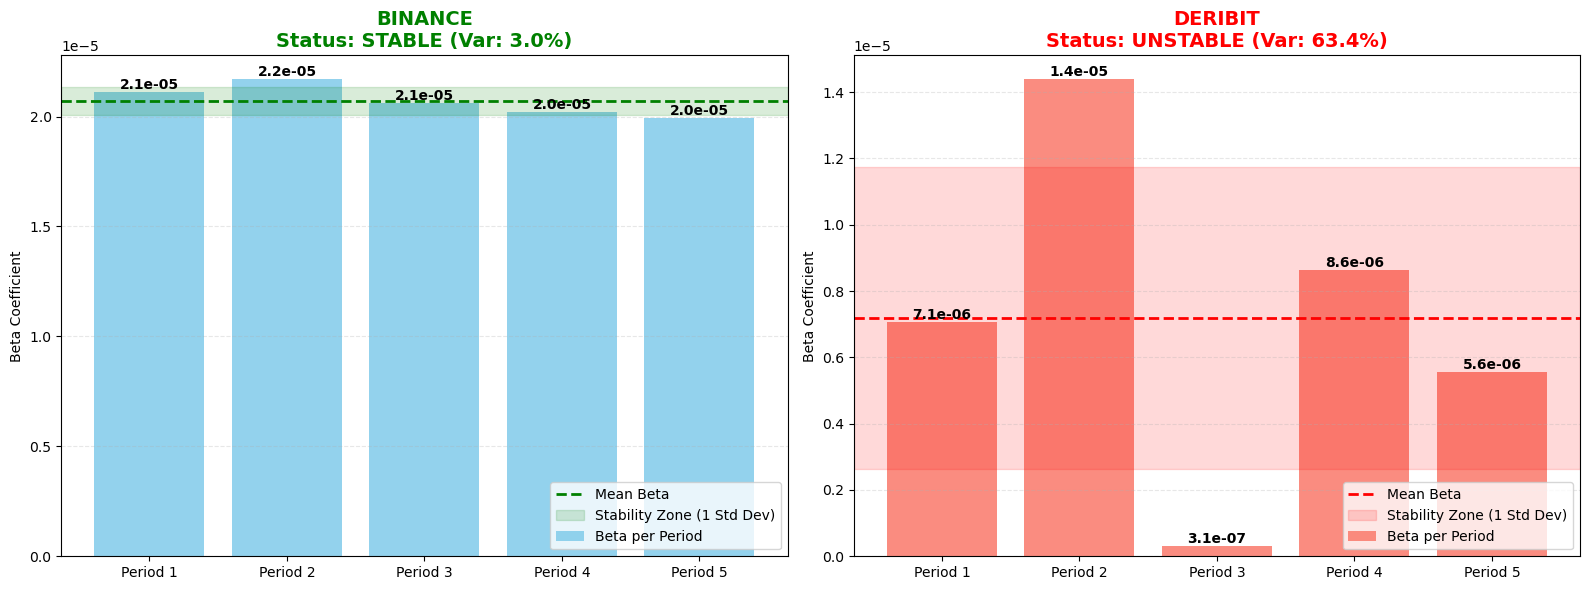

In [29]:
# --- Configuration ---
targets = ['BINANCE', 'DERIBIT']
n_splits = 5

# Create a 1x2 side-by-side layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, exchange in enumerate(targets):
    ax = axes[i] # Pick the specific subplot
    
    # 1. Get & Clean Data
    # ------------------------------------------
    # Assumes trades_df and MAX_TRADES_PER_EXCHANGE are defined in your env
    raw_data = trades_df[trades_df['Exchange'] == exchange].iloc[:MAX_TRADES_PER_EXCHANGE].copy()
    
    if raw_data.empty:
        ax.text(0.5, 0.5, "No Data", ha='center', va='center')
        continue

    clean_df = preprocess_data(raw_data, exchange)
    
    # Calculate Forward Returns (1s Horizon)
    df_res = clean_df.reset_index()
    df_res['target_time'] = df_res['ts'] + pd.Timedelta(seconds=1)
    future_lookup = df_res[['ts', 'trade_price']].copy()
    future_lookup.columns = ['ts', 'trade_price_fut'] 
    
    merged = pd.merge_asof(
        df_res[['ts', 'target_time']],      
        future_lookup,                      
        left_on='target_time',              
        right_on='ts',                      
        direction='backward'
    )
    clean_df['forward_return'] = (merged['trade_price_fut'].values - clean_df['trade_price'].values) / clean_df['trade_price'].values
    
    # Drop NaNs
    df = clean_df.dropna(subset=['trade_flow', 'forward_return'])
    # ------------------------------------------

    # 2. Calculate Betas per Chunk
    chunk_size = len(df) // n_splits
    betas = []
    indices = [f"Period {j+1}" for j in range(n_splits)] 
    
    for j in range(n_splits):
        start = j * chunk_size
        end = (j + 1) * chunk_size
        chunk = df.iloc[start:end]
        
        X = chunk[['trade_flow']].values
        y = chunk['forward_return'].values
        
        if len(X) > 100:
            model = LinearRegression().fit(X, y)
            betas.append(model.coef_[0])
        else:
            betas.append(0.0)

    # 3. Plotting
    beta_mean = np.mean(betas)
    beta_std = np.std(betas)
    cv = beta_std / abs(beta_mean) if beta_mean != 0 else 0

    # Color Logic: Green theme for Stable (Binance), Red theme for Unstable (Deribit)
    theme_color = 'green' if cv < 0.5 else 'red'
    bar_color = 'skyblue' if cv < 0.5 else 'salmon'

    # Bars
    bars = ax.bar(indices, betas, color=bar_color, alpha=0.9, label='Beta per Period')
    
    # Mean Line & Stability Zone
    ax.axhline(y=beta_mean, color=theme_color, linestyle='--', linewidth=2, label=f'Mean Beta')
    ax.axhspan(beta_mean - beta_std, beta_mean + beta_std, color=theme_color, alpha=0.15, label='Stability Zone (1 Std Dev)')

    # Formatting
    status_text = "STABLE" if cv < 0.5 else "UNSTABLE"
    ax.set_title(f"{exchange}\nStatus: {status_text} (Var: {cv:.1%})", fontsize=14, fontweight='bold', color=theme_color)
    ax.set_ylabel("Beta Coefficient")
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.legend(loc='lower right')
    
    # Add value labels (Scientific Notation for readability)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1e}', 
                ha='center', va='bottom' if height > 0 else 'top', 
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show() # Use plt.savefig('binance_vs_deribit.png') to save

## Beta Stability Comparison (Binance vs. Deribit) 
**Binance was the gold standard for stability**, with the Beta coefficient varying by only 3% across all time blocks.

By contrast, **Deribit exhibited extreme instability** (63% variation); the venue lacked sufficient continuous liquidity to support a stable regression

# 6. Performance Analysis 
Having validated the statistical stability of our Order Flow Imbalance signal, we now assess its financial efficacy. 

This section analyzes risk-adjusted returns across the full multi-exchange backtest, focusing on three key metrics:
1. **Sharpe Ratio**
2. **Maximum Drawdown**
3. **Tail Risk**

In [30]:
def analyze_performance_metrics(results_input):
    metrics_list = []
    
    if isinstance(results_input, list):
        results_dict = {item['Exchange']: item for item in results_input}
    else:
        results_dict = results_input
    
    for exchange, stats in results_dict.items():
        if 'Trades_DF' not in stats or stats['Trades_DF'] is None:
            continue
            
        df = stats['Trades_DF'].copy()
        
        # --- CRITICAL FIX: Ensure Index is Datetime ---
        # 1. Recover timestamp from 'original_ts'
        df['ts'] = pd.to_datetime(df['original_ts'])
        # 2. Set as index and sort
        df = df.set_index('ts').sort_index()
        
        # --- ROBUST EQUITY CURVE CALCULATION ---
        cum_cash = df['net_cash_change'].cumsum()
        inventory_value = df['inventory'] * df['trade_price']
        equity_curve = cum_cash + inventory_value
        
        # --- Drawdown ---
        running_max = equity_curve.cummax()
        drawdown = equity_curve - running_max
        max_drawdown = drawdown.min()

        # --- Metrics ---
        net_pnl = stats['Total Net P&L']
        gross_pnl = stats['Total Gross P&L']
        fees_paid = stats['Fees Paid']
        
        trade_pnl_series = equity_curve.diff().fillna(0)
        sharpe_trade = trade_pnl_series.mean() / (trade_pnl_series.std() + 1e-9)
        
        # --- Volatility Correlation ---
        # Explicitly ensure equity_curve has the datetime index for resampling
        equity_curve.index = df.index 
        
        pnl_5min = equity_curve.diff().resample('5min').sum()
        
        if not df.empty:
            vol_5min = df['trade_price'].pct_change().resample('5min').std()
            aligned = pd.concat([pnl_5min, vol_5min], axis=1).dropna()
            aligned.columns = ['PnL', 'Volatility']
            vol_correlation = aligned['PnL'].corr(aligned['Volatility']) if len(aligned) > 2 else np.nan
        else:
            vol_correlation = np.nan
            
        metrics_list.append({
            'Exchange': exchange,
            'Gross P&L ($)': gross_pnl,
            'Net P&L ($)': net_pnl,
            'Fees ($)': fees_paid,
            'Max Drawdown ($)': max_drawdown,
            'Trade Sharpe': sharpe_trade,
            'Vol Correlation': vol_correlation
        })
        
    return pd.DataFrame(metrics_list)

# --- RUN ---
perf_df = analyze_performance_metrics(all_results)

# Format
format_mapping = {
    'Gross P&L ($)': '${:,.0f}',    
    'Net P&L ($)': '${:,.0f}',     
    'Fees ($)': '${:,.0f}',          
    'Max Drawdown ($)': '${:,.0f}',  
    'Trade Sharpe': '{:.4f}',        
    'Vol Correlation': '{:.4f}'      
}

perf_df.style.format(format_mapping)

,Exchange,Gross P&L ($),Net P&L ($),Fees ($),Max Drawdown ($),Trade Sharpe,Vol Correlation
0,OKX,"$585,392","$575,712","$9,680","$-1,245,464",0.0006,-0.0150
1,GATE_IO,"$-77,079","$-89,412","$12,333","$-1,326,378",-0.0001,0.0133
2,COINBASE,"$-147,914","$-150,631","$2,717","$-1,115,566",-0.0015,0.0124
3,DERIBIT,"$-5,299","$-5,629",$330,"$-229,048",-0.0003,-0.0043
4,BITSTAMP,"$-401,556","$-401,670",$114,"$-428,751",-0.0829,0.0265
5,BINANCE,"$9,785","$7,119","$2,666","$-1,113,825",0.0000,-0.0455


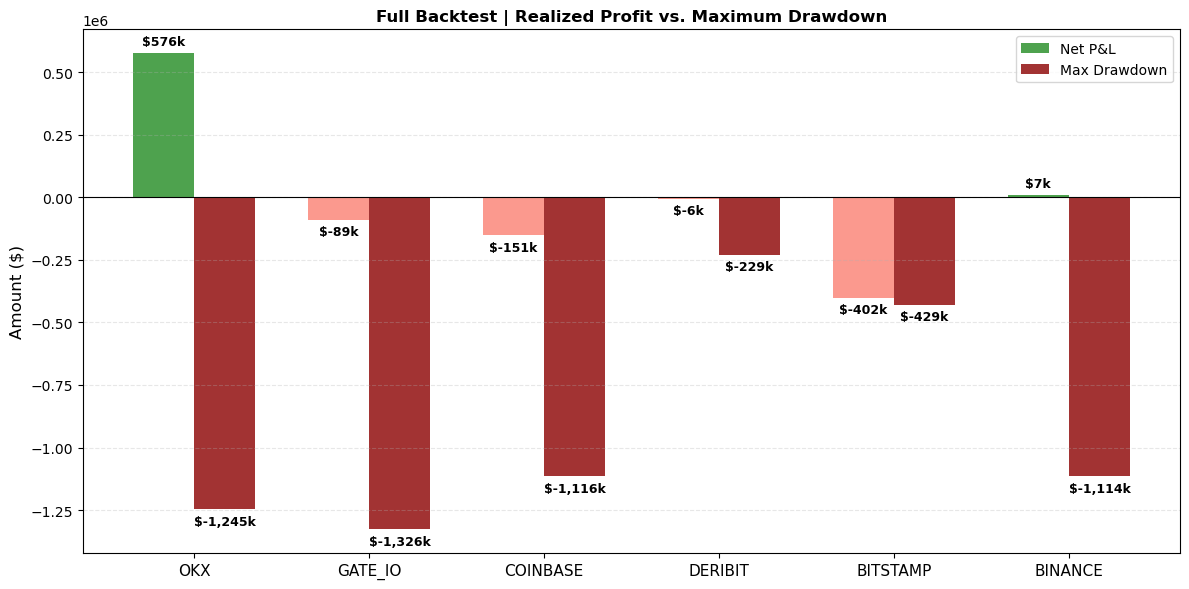

In [31]:
# 1. Prepare Data 
plot_df = perf_df.copy()

# Rename columns to remove ' ($)' for easier access, if necessary
plot_df.columns = [c.replace(' ($)', '') for c in plot_df.columns]
exchanges = plot_df['Exchange']
net_pnl = plot_df['Net P&L']
max_dd = plot_df['Max Drawdown']

# 2. Setup Figure
fig, ax = plt.subplots(figsize=(12, 6))

# Bar coordinates
x = np.arange(len(exchanges))
width = 0.35

# 3. Plot Net P&L (Left Bar)
pnl_colors = ['forestgreen' if val >= 0 else 'salmon' for val in net_pnl]
rects1 = ax.bar(x - width/2, net_pnl, width, label='Net P&L', color=pnl_colors, alpha=0.8)

# 4. Plot Max Drawdown (Right Bar)
# Color: Dark Red to signify "Deep Risk"
rects2 = ax.bar(x + width/2, max_dd, width, label='Max Drawdown', color='darkred', alpha=0.8)

# 5. Formatting
ax.set_title('Full Backtest | Realized Profit vs. Maximum Drawdown', fontsize=12, fontweight='bold')
ax.set_ylabel('Amount ($)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(exchanges, fontsize=11, rotation=0) # Rotation 0 is usually fine for 6 items
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(loc='upper right')

# 6. Dynamic Labels Function
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height == 0: continue
        
        # Position logic
        xy_pos = (rect.get_x() + rect.get_width() / 2, height)
        
        # If bar is positive (Profit), label above. If negative (Loss/Drawdown), label below.
        va = 'bottom' if height > 0 else 'top'
        y_offset = 4 if height > 0 else -4
        
        ax.annotate(f'${height/1000:,.0f}k',
                    xy=xy_pos,
                    xytext=(0, y_offset),
                    textcoords="offset points",
                    ha='center', va=va, fontsize=9, fontweight='bold')

# Apply labels
autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show() 

While the strategy generates a substantial Net P&L of $575k on OKX, the **Risk-to-Reward profile is untenable.**

The Maximum Drawdown of -$1.2M suggests that the strategy lacks an 'Exit Logic' to complement its 'Entry Alpha.'
* The model enters trades based on a 1-second predictive horizon but maintains those positions indefinitely if the signal does not reverse.
* This exposes the portfolio to significant Inventory Risk, where a maximum-capacity position (10 BTC) can be held against a trending market.

# 7. Removing Inventory Limits 
We will now perform the final stress test. 

We compare the strategy with a strict inventory cap (10 units) versus an unconstrained version (1,000,000 units) on the OKX exchange. 

In [32]:
# --- CONFIGURATION ---
EXCHANGE_TO_TEST = 'OKX'
LIMIT_CAPPED = 10.0
LIMIT_UNCAPPED = 1_000_000.0  # Effectively infinite

print(f"--- Running Inventory Limit Experiment on {EXCHANGE_TO_TEST} ---\n")

# 1. Prepare Data (Truncate & Preprocess)
raw_df = trades_df[trades_df['Exchange'] == EXCHANGE_TO_TEST].copy()

if len(raw_df) > MAX_TRADES_PER_EXCHANGE:
    raw_df = raw_df.iloc[:MAX_TRADES_PER_EXCHANGE].copy()

clean_df = preprocess_data(raw_df, EXCHANGE_TO_TEST)

# 2. Generate Signals
trades_df_output, msg = generate_signals(
    clean_df, 
    DEFAULT_TAU_STR, 
    DEFAULT_T_SECONDS, 
    DEFAULT_TARGET_PARTICIPATION
)

if trades_df_output is None:
    print(f"Error: Could not generate signals for {EXCHANGE_TO_TEST}. ({msg})")
else:
    # 3. Run Accounting: Scenario A (Capped)
    print(f"Running Scenario A: Capped Inventory (Limit={LIMIT_CAPPED})...")
    stats_capped = calculate_accounting(trades_df_output, DEFAULT_COST_BPS, max_inventory_limit=LIMIT_CAPPED)
    
    # 4. Run Accounting: Scenario B (Uncapped)
    print(f"Running Scenario B: Uncapped Inventory (Limit={LIMIT_UNCAPPED})...")
    stats_uncapped = calculate_accounting(trades_df_output, DEFAULT_COST_BPS, max_inventory_limit=LIMIT_UNCAPPED)

    # 5. Display Comparison Results
    print("\n" + "="*50)
    print(f"RESULTS COMPARISON: {EXCHANGE_TO_TEST}")
    print("="*50)
    
    # Calculate Drawdowns manually for the table
    dd_capped = (stats_capped['Trades_DF']['net_cash_change'].cumsum() - stats_capped['Trades_DF']['net_cash_change'].cumsum().cummax()).min()
    dd_uncapped = (stats_uncapped['Trades_DF']['net_cash_change'].cumsum() - stats_uncapped['Trades_DF']['net_cash_change'].cumsum().cummax()).min()

    comparison_data = {
        'Metric': ['Total Executed Trades', 'Final Inventory', 'Total Net P&L', 'Max Drawdown', 'Fees Paid'],
        f'Capped (Limit={LIMIT_CAPPED})': [
            stats_capped['Total Trades'], 
            stats_capped['Final Inventory'],
            stats_capped['Total Net P&L'],
            dd_capped,
            stats_capped['Fees Paid']
        ],
        f'Uncapped (Limit={LIMIT_UNCAPPED:,.0f})': [
            stats_uncapped['Total Trades'], 
            stats_uncapped['Final Inventory'],
            stats_uncapped['Total Net P&L'],
            dd_uncapped,
            stats_uncapped['Fees Paid']
        ]
    }
    
    comp_df = pd.DataFrame(comparison_data)
    
    # --- DISPLAY FIX: HIDE INDEX & FORMAT NUMBERS ---
    styled_comp = comp_df.style.format({
        f'Capped (Limit={LIMIT_CAPPED})': '{:,.2f}',
        f'Uncapped (Limit={LIMIT_UNCAPPED:,.0f})': '{:,.2f}'
    }).hide(axis='index') # <--- This hides the 0,1,2,3 index
    
    display(styled_comp)

--- Running Inventory Limit Experiment on OKX ---

Running Scenario A: Capped Inventory (Limit=10.0)...
Running Scenario B: Uncapped Inventory (Limit=1000000.0)...

RESULTS COMPARISON: OKX


Metric,Capped (Limit=10.0),"Uncapped (Limit=1,000,000)"
Total Executed Trades,"75,513.00","90,000.00"
Final Inventory,8.75,643.06
Total Net P&L,"575,712.02","785,718.29"
Max Drawdown,"-1,246,417.60","-62,387,893.65"
Fees Paid,"9,679.71","13,777.01"


Without limits, the strategy "chased" the market, accumulating over 643 BTC in inventory.

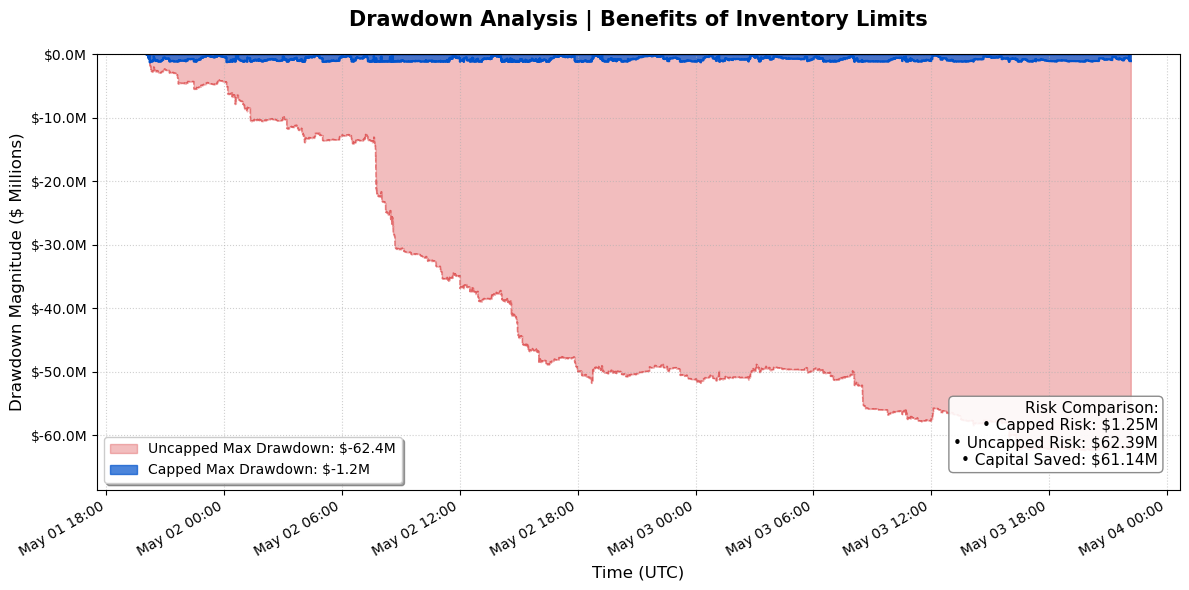

In [33]:
def plot_drawdown_analysis(capped_stats, uncapped_stats, exchange_name="OKX"):
    # Create single focus figure
    fig, ax = plt.subplots(figsize=(12, 6))

    # --- 1. Data Preparation ---
    df_cap = capped_stats['Trades_DF'].sort_values('original_ts').set_index('original_ts')
    df_uncap = uncapped_stats['Trades_DF'].sort_values('original_ts').set_index('original_ts')

    # Calculate Cumulative P&L to derive Drawdown (in Millions)
    pnl_cap = df_cap['net_cash_change'].cumsum() / 1_000_000
    pnl_uncap = df_uncap['net_cash_change'].cumsum() / 1_000_000
    
    # Drawdown = Current Value - Running Maximum
    dd_cap = (pnl_cap - pnl_cap.cummax())
    dd_uncap = (pnl_uncap - pnl_uncap.cummax())

    # --- 2. Plotting the "Underwater" Profiles ---
    # Uncapped (The "Risk" Profile)
    ax.fill_between(dd_uncap.index, dd_uncap, 0, color='#d62728', alpha=0.3, 
                    label=f'Uncapped Max Drawdown: ${dd_uncap.min():.1f}M')
    ax.plot(dd_uncap.index, dd_uncap, color='#d62728', linestyle='--', alpha=0.5, linewidth=1)

    # Capped (The "Controlled" Profile)
    ax.fill_between(dd_cap.index, dd_cap, 0, color='#0052cc', alpha=0.7, 
                    label=f'Capped Max Drawdown: ${dd_cap.min():.1f}M')
    ax.plot(dd_cap.index, dd_cap, color='#0052cc', linewidth=1.5)

    # --- 3. Formatting ---
    ax.set_title(f"Drawdown Analysis | Benefits of Inventory Limits", fontsize=15, fontweight='bold', pad=20)
    ax.set_ylabel("Drawdown Magnitude ($ Millions)", fontsize=12)
    ax.set_xlabel("Time (UTC)", fontsize=12)
    
    # Focus the Y-axis on the losses
    ax.set_ylim(dd_uncap.min() * 1.1, 0.1) 
    
    # Format Y-axis as Millions
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('$%.1fM'))
    
    # Grid and Legend
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower left', frameon=True, shadow=True)

    # Date Formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
    fig.autofmt_xdate()
    
    # Annotation Box for the "Big Problem"
    text_str = (f"Risk Comparison:\n"
                f"• Capped Risk: ${abs(dd_cap.min()):.2f}M\n"
                f"• Uncapped Risk: ${abs(dd_uncap.min()):.2f}M\n"
                f"• Capital Saved: ${abs(dd_uncap.min() - dd_cap.min()):.2f}M")
    
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    ax.text(0.98, 0.05, text_str, transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', horizontalalignment='right', bbox=props)

    plt.tight_layout()
    plt.show()

# Run the Drawdown Focus Plot
plot_drawdown_analysis(stats_capped, stats_uncapped, exchange_name="OKX")

Without limits, **algorithms can accumulate massive losses.** 

The Capped Inventory (10.0) setting is the only version that is even remotely tradeable; the Uncapped version would have resulted in immediate bankruptcy for almost any trading desk.

# 8. Conclusion 

### Performance & Risk Assessment 
Our comprehensive backtest of the Order Flow Imbalance (OFI) strategy reveals a **high-alpha signal that is undermined by extreme directional risk and a lack of generalizability.**

Under optimized settings, the strategy generated a Net P&L of 575,712 on OKX.
* However, on the same exchange, the Maximum Drawdown of -1.2M was more than double the total profit.

The strategy enters trades based on a 1-second predictive horizon but **lacks a formal exit logic.** 
* Without a limit, the strategy suffered a catastrophic -$62.3M drawdown by "averaging down" into losing trends.


### Future Expectations & Scalability
**A longer test period will likely reveal the "hidden costs"** that short backtests often miss:
* Network latency spikes on OKX will result in "slippage," where you intend to buy at $X$ but actually fill at $X+1$.
* Over thousands of trades, this 1-tick difference can turn a profitable strategy into a losing one.

As we try to scale the strategy to higher profits, you will hit a liquidity ceiling.
* Currently, our trade size is likely small. If we tried to increase the limit from 10 BTC to 100 BTC, our orders will begin to move the market (Adverse Selection).